# 1. 준비

In [ ]:
!pip install optuna

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score
from sklearn.metrics import make_scorer, mean_squared_error

from sklearn.ensemble import RandomForestRegressor
from lightgbm import LGBMRegressor
import optuna
from sklearn.model_selection import KFold

import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
path = '/content/drive/MyDrive/Colab/DataAnalytics/icu_final_feature_set.csv'
df = pd.read_csv(path)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16394 entries, 0 to 16393
Data columns (total 55 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   los                      16394 non-null  float64
 1   gender                   16394 non-null  object 
 2   race_simplified          16394 non-null  object 
 3   anchor_age               16394 non-null  int64  
 4   anchor_year              16394 non-null  int64  
 5   RR_48h_max               16394 non-null  int64  
 6   HR_48h_mean              16394 non-null  float64
 7   Temp_48h_min             16394 non-null  float64
 8   RR_48h_min               16394 non-null  int64  
 9   SpO2_48h_mean            16394 non-null  float64
 10  HR_48h_std               16394 non-null  float64
 11  HR_48h_max               16394 non-null  int64  
 12  RR_48h_mean              16394 non-null  float64
 13  Temp_48h_std             16394 non-null  float64
 14  GCS_Motor_48h_min     

# 2. 전처리

In [ ]:
# 결측치 확인
df.isnull().sum()

,0
los,0
gender,0
race_simplified,0
anchor_age,0
anchor_year,0
RR_48h_max,0
HR_48h_mean,0
Temp_48h_min,0
RR_48h_min,0
SpO2_48h_mean,0


In [ ]:
# 범주형 변수 원핫 인코딩
df = pd.get_dummies(df, columns=['gender', 'race_simplified'], drop_first=True)

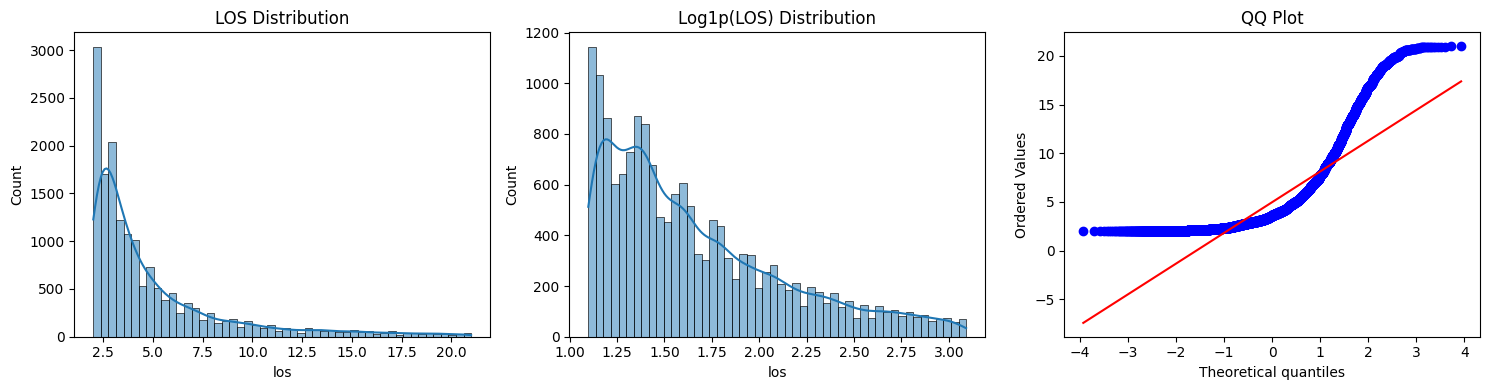

In [ ]:
# LoS 분포 확인
plt.figure(figsize=(15,4))

# 1) 히스토그램 (원본)
plt.subplot(1,3,1)
sns.histplot(df["los"], bins=50, kde=True)
plt.title("LOS Distribution")

# 2) 로그 변환 후 히스토그램
plt.subplot(1,3,2)
sns.histplot(np.log1p(df["los"]), bins=50, kde=True)
plt.title("Log1p(LOS) Distribution")

# 3) Q-Q plot
plt.subplot(1,3,3)
stats.probplot(df["los"], dist="norm", plot=plt)
plt.title("QQ Plot")

plt.tight_layout()
plt.show()

In [ ]:
# 타겟 변수 로그 변환
df["los_log"] = np.log1p(df["los"])

# y = log-transformed LOS
y = df["los_log"]

# X = 모든 나머지 feature (los, los_log 제외)
X = df.drop(columns=["los", "los_log"])

In [ ]:
# 훈련/테스트 분할

# 8:2
X_train_80, X_test_20, y_train_80, y_test_20 = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 7:3
X_train_70, X_test_30, y_train_70, y_test_30 = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [ ]:
# 각각 스케일링
scaler_80 = StandardScaler()
X_train_80_scaled = scaler_80.fit_transform(X_train_80)
X_test_20_scaled  = scaler_80.transform(X_test_20)

scaler_70 = StandardScaler()
X_train_70_scaled = scaler_70.fit_transform(X_train_70)
X_test_30_scaled  = scaler_70.transform(X_test_30)

# 3. 모델링 - RandomForest (훈련/테스트: 80/20)

In [ ]:
# 8:2 랜덤포레스트 베이스 모델 학습 (디폴트값)
rf_baseline = RandomForestRegressor(random_state=42)

rf_baseline.fit(X_train_80_scaled, y_train_80)

RandomForestRegressor(random_state=42)

In [ ]:
# 랜덤포레스트 베이스 모델 예측
y_pred_log = rf_baseline.predict(X_test_20_scaled)

In [ ]:
# 평가함수 생성
def evaluate(model, X_train, y_train_log, X_test, y_test_log, name="Model"):

    # 1) 예측 (log-space)
    pred_train_log = model.predict(X_train)
    pred_test_log  = model.predict(X_test)

    # 2) 역변환
    y_train = np.exp(y_train_log)
    y_test  = np.exp(y_test_log)
    pred_train = np.exp(pred_train_log)
    pred_test  = np.exp(pred_test_log)

    # 3) 올바른 RMSE 계산
    rmse_train = np.sqrt(mean_squared_error(y_train, pred_train))
    rmse_test  = np.sqrt(mean_squared_error(y_test, pred_test))

    mae_test   = mean_absolute_error(y_test, pred_test)
    r2_test    = r2_score(y_test, pred_test)

    # 4) 출력
    print(f"\n===== {name} =====")
    print(f"Train RMSE: {rmse_train:.4f}")
    print(f"Test RMSE : {rmse_test:.4f}")
    print(f"Test MAE  : {mae_test:.4f}")
    print(f"Test R²   : {r2_test:.4f}")

    return rmse_test, mae_test, r2_test

In [ ]:
evaluate(
    rf_baseline,
    X_train_80_scaled, y_train_80,
    X_test_20_scaled,  y_test_20,
    name="RandomForest (8:2 Baseline)"
)


===== RandomForest (8:2 Baseline) =====
Train RMSE: 1.4323
Test RMSE : 3.1334
Test MAE  : 1.9910
Test R²   : 0.2593


(np.float64(3.1334495798893798), 1.9909537612415174, 0.25927795204412474)

optuna 활용하여 튜닝

In [ ]:
# Objective 함수 정의
def objective(trial):

    # 하이퍼파라미터 샘플링
    n_estimators     = trial.suggest_int("n_estimators", 100, 800)
    max_depth        = trial.suggest_int("max_depth", 5, 40)
    min_split        = trial.suggest_int("min_samples_split", 2, 10)
    min_leaf         = trial.suggest_int("min_samples_leaf", 1, 8)
    max_features_opt = trial.suggest_categorical("max_features", ["sqrt", None])

    # 모델 정의
    model = RandomForestRegressor(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_split,
        min_samples_leaf=min_leaf,
        max_features=max_features_opt,
        random_state=42,
        n_jobs=-1
    )

    # 학습 (log-space)
    model.fit(X_train_80_scaled, y_train_80)

    # 예측 (log-space)
    pred_log = model.predict(X_test_20_scaled)

    # inverse transform
    y_test_real  = np.exp(y_test_20)
    pred_real    = np.exp(pred_log)

    # RMSE(real-space)
    rmse_real = np.sqrt(mean_squared_error(y_test_real, pred_real))

    return rmse_real

In [ ]:
# Optuna Study 실행
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=30)

print("Best RMSE (real-space):", study.best_value)
print("Best Params:", study.best_params)

[I 2025-12-07 14:41:59,254] A new study created in memory with name: no-name-fd38a876-2a6c-41dc-85f4-aa467d0faaff
[I 2025-12-07 14:45:37,664] Trial 0 finished with value: 3.124131100178 and parameters: {'n_estimators': 390, 'max_depth': 30, 'min_samples_split': 9, 'min_samples_leaf': 5, 'max_features': None}. Best is trial 0 with value: 3.124131100178.
[I 2025-12-07 14:48:32,279] Trial 1 finished with value: 3.1280002195041083 and parameters: {'n_estimators': 254, 'max_depth': 36, 'min_samples_split': 3, 'min_samples_leaf': 4, 'max_features': None}. Best is trial 0 with value: 3.124131100178.
[I 2025-12-07 14:48:48,823] Trial 2 finished with value: 3.143128905169633 and parameters: {'n_estimators': 303, 'max_depth': 39, 'min_samples_split': 3, 'min_samples_leaf': 8, 'max_features': 'sqrt'}. Best is trial 0 with value: 3.124131100178.
[I 2025-12-07 14:51:45,304] Trial 3 finished with value: 3.1261382819660866 and parameters: {'n_estimators': 448, 'max_depth': 40, 'min_samples_split': 3,

Best RMSE (real-space): 3.121855765575108
Best Params: {'n_estimators': 373, 'max_depth': 26, 'min_samples_split': 8, 'min_samples_leaf': 2, 'max_features': None}


In [ ]:
# 최종 best model 재학습
rf_best = RandomForestRegressor(
    n_estimators=373,
    max_depth=26,
    min_samples_split=8,
    min_samples_leaf=2,
    max_features=None,
    random_state=42,
    n_jobs=-1
)

rf_best.fit(X_train_80_scaled, y_train_80)

RandomForestRegressor(max_depth=26, max_features=None, min_samples_leaf=2,
                      min_samples_split=8, n_estimators=373, n_jobs=-1,
                      random_state=42)

In [ ]:
# 튜닝 후 모델 평가
evaluate(rf_best,X_train_80_scaled, y_train_80, X_test_20_scaled,  y_test_20,
    name="RandomForest (8:2 Tuned)"
)


===== RandomForest (8:2 Tuned) =====
Train RMSE: 1.8345
Test RMSE : 3.1219
Test MAE  : 1.9775
Test R²   : 0.2647


(np.float64(3.121855765575108), 1.9774645425305832, 0.26474917867506387)

In [ ]:
# k-fold 교차 검증
def cross_validate_real_rmse_mae(model, X, y_log, cv=5):

    X = np.array(X)
    y_log = np.array(y_log)

    kf = KFold(n_splits=cv, shuffle=True, random_state=42)

    rmse_list = []
    mae_list = []

    for train_idx, valid_idx in kf.split(X):
        X_tr, X_val = X[train_idx], X[valid_idx]
        y_tr_log = y_log[train_idx]
        y_val_log = y_log[valid_idx]

        # 1) 모델 학습 (log-space)
        model.fit(X_tr, y_tr_log)

        # 2) 예측(log-space)
        pred_log = model.predict(X_val)

        # 3) 역변환(real-space)
        y_val = np.exp(y_val_log)
        pred = np.exp(pred_log)

        # 4) RMSE / MAE 계산
        rmse = np.sqrt(mean_squared_error(y_val, pred))
        mae = mean_absolute_error(y_val, pred)

        rmse_list.append(rmse)
        mae_list.append(mae)

    print(f"Real-space CV RMSE (each fold): {rmse_list}")
    print(f"Real-space CV RMSE Mean       : {np.mean(rmse_list):.4f}")
    print(f"Real-space CV RMSE Std        : {np.std(rmse_list):.4f}")
    print()
    print(f"Real-space CV MAE (each fold): {mae_list}")
    print(f"Real-space CV MAE Mean       : {np.mean(mae_list):.4f}")
    print(f"Real-space CV MAE Std        : {np.std(mae_list):.4f}")

    return rmse_list, mae_list

In [ ]:
# rf_baseline 교차검증
print("\n===== RF Baseline (8:2) — 5-fold CV =====")
rmse_list, mae_list = cross_validate_real_rmse_mae(
    rf_baseline,
    X_train_80_scaled,
    y_train_80,
    cv=5
)


===== RF Baseline (8:2) — 5-fold CV =====
Real-space CV RMSE (each fold): [np.float64(3.2447857483484386), np.float64(3.0901162025793765), np.float64(3.136608630888591), np.float64(3.0325345756824955), np.float64(3.1632589799586244)]
Real-space CV RMSE Mean       : 3.1335
Real-space CV RMSE Std        : 0.0712

Real-space CV MAE (each fold): [2.0385840460391784, 1.9563014756449757, 1.9821132888499278, 1.9383751434384453, 2.006870095957541]
Real-space CV MAE Mean       : 1.9844
Real-space CV MAE Std        : 0.0356


In [ ]:
# rf_tuned 교차검증
print("\n===== RF Tuned (8:2) — 5-fold CV =====")
rmse_tuned_list, mae_tuned_list = cross_validate_real_rmse_mae(
    rf_best,
    X_train_80_scaled,
    y_train_80,
    cv=5
)


===== RF Tuned (8:2) — 5-fold CV =====
Real-space CV RMSE (each fold): [np.float64(3.2325599008158616), np.float64(3.0760307417324593), np.float64(3.13037917242673), np.float64(3.0352487013218252), np.float64(3.156665104423136)]
Real-space CV RMSE Mean       : 3.1262
Real-space CV RMSE Std        : 0.0679

Real-space CV MAE (each fold): [2.0200293246450913, 1.9443089645944474, 1.9761389768719388, 1.9319566368862222, 1.9995662258339681]
Real-space CV MAE Mean       : 1.9744
Real-space CV MAE Std        : 0.0329


In [ ]:
# rf_baseline 교차검증(k=7)
print("\n===== RF Baseline (8:2) — 7-fold CV =====")
rmse_base_list, mae_base_list = cross_validate_real_rmse_mae(
    rf_baseline,
    X_train_80_scaled,
    y_train_80,
    cv=7
)


===== RF Baseline (8:2) — 7-fold CV =====
Real-space CV RMSE (each fold): [np.float64(3.2738841861962293), np.float64(3.205707098004515), np.float64(2.999668120530007), np.float64(3.134036918891068), np.float64(2.9843541669977274), np.float64(3.198566326365223), np.float64(3.1167545996652035)]
Real-space CV RMSE Mean       : 3.1304
Real-space CV RMSE Std        : 0.0997

Real-space CV MAE (each fold): [2.048387758984052, 2.0286099412830993, 1.912503757583452, 1.9953115679143105, 1.9267208849423663, 2.017696574287337, 1.9869383678746335]
Real-space CV MAE Mean       : 1.9880
Real-space CV MAE Std        : 0.0473


In [ ]:
# rf_tuned 교차검증(k=7)
print("\n===== RF Tuned (8:2) — 7-fold CV =====")
rmse_tuned_list, mae_tuned_list = cross_validate_real_rmse_mae(
    rf_best,
    X_train_80_scaled,
    y_train_80,
    cv=7
)


===== RF Tuned (8:2) — 7-fold CV =====
Real-space CV RMSE (each fold): [np.float64(3.253118619772592), np.float64(3.2047661612087595), np.float64(2.995267123959398), np.float64(3.12344536978041), np.float64(2.9877006197653655), np.float64(3.194947012282251), np.float64(3.1120551134904435)]
Real-space CV RMSE Mean       : 3.1245
Real-space CV RMSE Std        : 0.0953

Real-space CV MAE (each fold): [2.023800541640521, 2.0173935176498787, 1.9066332840763618, 1.9728304045702272, 1.9132502263768576, 2.009695396116402, 1.9729359682120975]
Real-space CV MAE Mean       : 1.9738
Real-space CV MAE Std        : 0.0445


# 3. 모델링 - RandomForest (훈련/테스트: 70/30)

In [ ]:
# 7:3 랜덤포레스트 베이스 모델 학습 (디폴트값)
rf_baseline_70 = RandomForestRegressor(random_state=42)

rf_baseline_70.fit(X_train_70_scaled, y_train_70)

RandomForestRegressor(random_state=42)

In [ ]:
# 랜덤포레스트 베이스 모델 예측
evaluate(rf_baseline_70, X_train_70_scaled, y_train_70, X_test_30_scaled,  y_test_30,
    name="RandomForest (7:3 Baseline)"
)


===== RandomForest (7:3 Baseline) =====
Train RMSE: 1.4432
Test RMSE : 3.0709
Test MAE  : 1.9627
Test R²   : 0.2696


(np.float64(3.070923118789961), 1.9626831991658475, 0.26957665122306507)

optuna 활용하여 튜닝

In [ ]:
# Objective 함수 정의
def objective_rf_70(trial):

    # 하이퍼파라미터 샘플링
    n_estimators     = trial.suggest_int("n_estimators", 100, 800)
    max_depth        = trial.suggest_int("max_depth", 5, 40)
    min_split        = trial.suggest_int("min_samples_split", 2, 10)
    min_leaf         = trial.suggest_int("min_samples_leaf", 1, 8)
    max_features_opt = trial.suggest_categorical("max_features", ["sqrt", None])

    # 모델 정의
    model = RandomForestRegressor(
        n_estimators      = n_estimators,
        max_depth         = max_depth,
        min_samples_split = min_split,
        min_samples_leaf  = min_leaf,
        max_features      = max_features_opt,
        random_state      = 42,
        n_jobs            = -1
    )

    # 학습 (log-space)
    model.fit(X_train_70_scaled, y_train_70)

    # 예측 (log-space)
    pred_log = model.predict(X_test_30_scaled)

    # inverse transform
    y_test_real  = np.exp(y_test_30)
    pred_real    = np.exp(pred_log)

    # RMSE (real-space)
    rmse_real = np.sqrt(mean_squared_error(y_test_real, pred_real))

    return rmse_real

In [ ]:
# Optuna Study 실행
study_70 = optuna.create_study(direction="minimize")
study_70.optimize(objective_rf_70, n_trials=30)

print("Best RMSE (real-space):", study_70.best_value)
print("Best Params:", study_70.best_params)

[I 2025-12-07 17:06:43,493] A new study created in memory with name: no-name-d4dcafad-ce32-4fdf-b583-d2382ad845b1
[I 2025-12-07 17:08:15,019] Trial 0 finished with value: 3.0801763917435387 and parameters: {'n_estimators': 354, 'max_depth': 10, 'min_samples_split': 8, 'min_samples_leaf': 2, 'max_features': None}. Best is trial 0 with value: 3.0801763917435387.
[I 2025-12-07 17:09:29,497] Trial 1 finished with value: 3.1104249199948546 and parameters: {'n_estimators': 496, 'max_depth': 6, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': None}. Best is trial 0 with value: 3.0801763917435387.
[I 2025-12-07 17:10:17,130] Trial 2 finished with value: 3.0865118322855927 and parameters: {'n_estimators': 551, 'max_depth': 20, 'min_samples_split': 8, 'min_samples_leaf': 5, 'max_features': 'sqrt'}. Best is trial 0 with value: 3.0801763917435387.
[I 2025-12-07 17:12:06,118] Trial 3 finished with value: 3.091697937722851 and parameters: {'n_estimators': 475, 'max_depth': 8, 'min_sam

Best RMSE (log-space): 3.06563449334891
Best Params: {'n_estimators': 530, 'max_depth': 22, 'min_samples_split': 6, 'min_samples_leaf': 3, 'max_features': None}


In [ ]:
# 최종 best model 재학습
rf_best_70 = RandomForestRegressor(
    n_estimators=530,
    max_depth=22,
    min_samples_split=6,
    min_samples_leaf=3,
    max_features=None,
    random_state=42,
    n_jobs=-1
)

rf_best_70.fit(X_train_70_scaled, y_train_70)

RandomForestRegressor(max_depth=22, max_features=None, min_samples_leaf=3,
                      min_samples_split=6, n_estimators=530, n_jobs=-1,
                      random_state=42)

In [ ]:
# 튜닝 후 모델 평가
evaluate(rf_best_70, X_train_70_scaled, y_train_70, X_test_30_scaled,  y_test_30,
    name="RandomForest (7:3 Tuned)"
)


===== RandomForest (7:3 Tuned) =====
Train RMSE: 1.8306
Test RMSE : 3.0656
Test MAE  : 1.9477
Test R²   : 0.2721


(np.float64(3.06563449334891), 1.9477463820295426, 0.27209029878534974)

In [ ]:
# 7:3 rf_baseline 교차검증
print("\n===== RF Baseline (7:3) — 5-fold CV =====")
rmse_list_70, mae_list_70 = cross_validate_real_rmse_mae(
    rf_baseline_70,            # baseline 모델
    X_train_70_scaled,
    y_train_70,
    cv=5
)


===== RF Baseline (7:3) — 5-fold CV =====
Real-space CV RMSE (each fold): [np.float64(3.116557706177032), np.float64(3.186598861915918), np.float64(3.093933971423577), np.float64(3.3850662841169976), np.float64(3.0318075182619917)]
Real-space CV RMSE Mean       : 3.1628
Real-space CV RMSE Std        : 0.1217

Real-space CV MAE (each fold): [1.9651257239826552, 2.0057622020543078, 1.9687001094935168, 2.135152224980045, 1.9629899729092306]
Real-space CV MAE Mean       : 2.0075
Real-space CV MAE Std        : 0.0657


In [ ]:
# 7:3 rf_tuned 교차검증
print("\n===== RF Tuned (7:3) — 5-fold CV =====")
rmse_tuned_list_70, mae_tuned_list_70 = cross_validate_real_rmse_mae(
    rf_best_70,                # tuned 모델
    X_train_70_scaled,
    y_train_70,
    cv=5
)


===== RF Tuned (7:3) — 5-fold CV =====
Real-space CV RMSE (each fold): [np.float64(3.110868748382169), np.float64(3.1829823401980013), np.float64(3.0816975088923253), np.float64(3.376461253441734), np.float64(3.024287782970223)]
Real-space CV RMSE Mean       : 3.1553
Real-space CV RMSE Std        : 0.1218

Real-space CV MAE (each fold): [1.9425661491246893, 1.9898048470074507, 1.9485036864636498, 2.113974857498857, 1.9487056387295718]
Real-space CV MAE Mean       : 1.9887
Real-space CV MAE Std        : 0.0649


In [ ]:
# 7:3 rf_baseline 교차검증(k=7)
print("\n===== RF Baseline (7:3) — 7-fold CV =====")
rmse_list_70, mae_list_70 = cross_validate_real_rmse_mae(
    rf_baseline_70,            # baseline 모델
    X_train_70_scaled,
    y_train_70,
    cv=7
)


===== RF Baseline (7:3) — 7-fold CV =====
Real-space CV RMSE (each fold): [np.float64(3.0796534517461867), np.float64(3.058540003560109), np.float64(3.256304913238408), np.float64(3.0947151288033097), np.float64(3.3322771688298976), np.float64(3.2725441156001343), np.float64(3.020347215972534)]
Real-space CV RMSE Mean       : 3.1592
Real-space CV RMSE Std        : 0.1147

Real-space CV MAE (each fold): [1.9509562058775511, 1.9475331871137778, 2.040386399624914, 1.9611865474262205, 2.1142259379416912, 2.0913196257320954, 1.9545677896121816]
Real-space CV MAE Mean       : 2.0086
Real-space CV MAE Std        : 0.0668


In [ ]:
# 7:3 rf_tuned 교차검증(k=7)
print("\n===== RF Tuned (7:3) — 7-fold CV =====")
rmse_tuned_list_70, mae_tuned_list_70 = cross_validate_real_rmse_mae(
    rf_best_70,                # tuned 모델
    X_train_70_scaled,
    y_train_70,
    cv=7
)


===== RF Tuned (7:3) — 7-fold CV =====
Real-space CV RMSE (each fold): [np.float64(3.0730163306025977), np.float64(3.0545251931525006), np.float64(3.2604200411524644), np.float64(3.084092051456498), np.float64(3.3177230466553196), np.float64(3.259837227868061), np.float64(3.015412704665771)]
Real-space CV RMSE Mean       : 3.1521
Real-space CV RMSE Std        : 0.1133

Real-space CV MAE (each fold): [1.9228604931759636, 1.926888739070567, 2.0226030365770264, 1.9429567669843792, 2.0912113922952247, 2.0762222617603765, 1.9338880926765813]
Real-space CV MAE Mean       : 1.9881
Real-space CV MAE Std        : 0.0682


# 4. 모델링 - LGBM(훈련/테스트: 80/20)

In [ ]:
# 8:2 LGBM 베이스 모델 학습 (디폴트값)
lgbm_baseline_80 = LGBMRegressor(random_state=42,n_jobs=-1)

lgbm_baseline_80.fit(X_train_80_scaled, y_train_80)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.008442 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 8305
[LightGBM] [Info] Number of data points in the train set: 13115, number of used features: 56
[LightGBM] [Info] Start training from score 1.657478


LGBMRegressor(n_jobs=-1, random_state=42)

In [ ]:
evaluate(lgbm_baseline_80, X_train_80_scaled, y_train_80, X_test_20_scaled,  y_test_20,
    name="LGBM (8:2 Baseline)"
)


===== LGBM (8:2 Baseline) =====
Train RMSE: 2.5180
Test RMSE : 3.1128
Test MAE  : 1.9569
Test R²   : 0.2690


(np.float64(3.1128014934889188), 1.9569175863317514, 0.26900786815611866)

optuna 활용하여 튜닝

In [ ]:
# Objective 함수 정의
def objective_lgbm(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 200, 800),
        "max_depth": trial.suggest_int("max_depth", 4, 40),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3),
        "num_leaves": trial.suggest_int("num_leaves", 20, 200),
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 50),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 0.0, 1.0),
        "reg_lambda": trial.suggest_float("reg_lambda", 0.0, 1.0),
        "random_state": 42,
        "n_jobs": -1
    }

    # 모델 생성
    model = LGBMRegressor(**params)

    # 로그 공간 학습
    model.fit(X_train_80_scaled, y_train_80)

    # 로그 공간 예측
    pred_log = model.predict(X_test_20_scaled)

    # 역변환(real-space)
    y_test_real = np.exp(y_test_20)
    pred_real   = np.exp(pred_log)

    # real-space RMSE
    rmse_real = np.sqrt(mean_squared_error(y_test_real, pred_real))

    return rmse_real

In [ ]:
# optuna 실행
study_lgbm = optuna.create_study(direction="minimize")
study_lgbm.optimize(objective_lgbm, n_trials=40, show_progress_bar=True)

[I 2025-12-07 19:17:07,184] A new study created in memory with name: no-name-af13c636-af7a-403d-8aab-9755e632e40e


  0%|          | 0/40 [00:00<?, ?it/s]

스트리밍 출력 내용이 길어서 마지막 5000줄이 삭제되었습니다.
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] Stopped training because there are no more leave

In [ ]:
print("\nBest RMSE (real-space):", study_lgbm.best_value)
print("Best Params:", study_lgbm.best_params)


Best RMSE (real-space): 3.0819278940673778
Best Params: {'n_estimators': 763, 'max_depth': 37, 'learning_rate': 0.02230217846945172, 'num_leaves': 52, 'min_child_samples': 31, 'subsample': 0.6560330493375917, 'colsample_bytree': 0.5813124645626746, 'reg_alpha': 0.33640365417219964, 'reg_lambda': 0.8998499110748984}


In [ ]:
# 최종 best LGBM 모델 재학습
lgbm_best_80 = LGBMRegressor(
    n_estimators=763,
    max_depth=37,
    learning_rate=0.02230217846945172,
    num_leaves=52,
    min_child_samples=31,
    subsample=0.6560330493375917,
    colsample_bytree=0.5813124645626746,
    reg_alpha=0.33640365417219964,
    reg_lambda=0.8998499110748984,
    random_state=42,
    n_jobs=-1
)

lgbm_best_80.fit(X_train_80_scaled, y_train_80)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.024324 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 8305
[LightGBM] [Info] Number of data points in the train set: 13115, number of used features: 56
[LightGBM] [Info] Start training from score 1.657478


LGBMRegressor(colsample_bytree=0.5813124645626746,
              learning_rate=0.02230217846945172, max_depth=37,
              min_child_samples=31, n_estimators=763, n_jobs=-1, num_leaves=52,
              random_state=42, reg_alpha=0.33640365417219964,
              reg_lambda=0.8998499110748984, subsample=0.6560330493375917)

In [ ]:
# 튜닝 후 모델 평가
evaluate(lgbm_best_80, X_train_80_scaled, y_train_80, X_test_20_scaled, y_test_20,
    name="LGBM (8:2 Tuned)"
)


===== LGBM (8:2 Tuned) =====
Train RMSE: 1.9694
Test RMSE : 3.0819
Test MAE  : 1.9423
Test R²   : 0.2834


(np.float64(3.0819278940673778), 1.942256418611316, 0.2834363106977532)

In [ ]:
# 5-fold 교차 검증
print("\n===== LGBM Baseline (8:2) — 5-fold CV =====")
rmse_lgbm_base_5, mae_lgbm_base_5 = cross_validate_real_rmse_mae(
    lgbm_baseline_80,
    X_train_80_scaled,
    y_train_80,
    cv=5
)


===== LGBM Baseline (8:2) — 5-fold CV =====
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.087909 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 8273
[LightGBM] [Info] Number of data points in the train set: 10492, number of used features: 56
[LightGBM] [Info] Start training from score 1.654780
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.012360 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 8280
[LightGBM] [Info] Number of data points in the train set: 10492, number of used features: 56
[LightGBM] [Info] Start training from score 1.659527
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003010 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `for

In [ ]:
# 5-fold 교차 검증
print("\n===== LGBM Tuned (8:2) — 5-fold CV =====")
rmse_lgbm_tuned_5, mae_lgbm_tuned_5 = cross_validate_real_rmse_mae(
    lgbm_best_80,
    X_train_80_scaled,
    y_train_80,
    cv=5
)


===== LGBM Tuned (8:2) — 5-fold CV =====
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.005983 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 8273
[LightGBM] [Info] Number of data points in the train set: 10492, number of used features: 56
[LightGBM] [Info] Start training from score 1.654780
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.005980 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 8280
[LightGBM] [Info] Number of data points in the train set: 10492, number of used features: 56
[LightGBM] [Info] Start training from score 1.659527
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.006142 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 8274
[LightGBM] [Info] Number of data points in the train set: 10492, number of use

In [ ]:
# 7-fold 교차 검증
print("\n===== LGBM Baseline (8:2) — 7-fold CV =====")
rmse_lgbm_tuned_7, mae_lgbm_tuned_7 = cross_validate_real_rmse_mae(
    lgbm_best_80,
    X_train_80_scaled,
    y_train_80,
    cv=7
)


===== LGBM Baseline (8:2) — 7-fold CV =====
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.006631 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 8297
[LightGBM] [Info] Number of data points in the train set: 11241, number of used features: 56
[LightGBM] [Info] Start training from score 1.655842
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.006503 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 8280
[LightGBM] [Info] Number of data points in the train set: 11241, number of used features: 56
[LightGBM] [Info] Start training from score 1.656761
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.006547 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 8286
[LightGBM] [Info] Number of data points in the train set: 11241, number of 

In [ ]:
# 7-fold 교차 검증
print("\n===== LGBM Tuned (8:2) — 7-fold CV =====")
rmse_lgbm_tuned_7, mae_lgbm_tuned_7 = cross_validate_real_rmse_mae(
    lgbm_best_80,
    X_train_80_scaled,
    y_train_80,
    cv=7
)


===== LGBM Tuned (8:2) — 7-fold CV =====
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.006662 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 8297
[LightGBM] [Info] Number of data points in the train set: 11241, number of used features: 56
[LightGBM] [Info] Start training from score 1.655842
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.006477 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 8280
[LightGBM] [Info] Number of data points in the train set: 11241, number of used features: 56
[LightGBM] [Info] Start training from score 1.656761
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.006908 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 8286
[LightGBM] [Info] Number of data points in the train set: 11241, number of use

# 4. 모델링 - LGBM(훈련/테스트: 70/30)

In [ ]:
# 7:3 LGBM 베이스 모델 학습 (디폴트값)
lgbm_baseline_70 = LGBMRegressor(random_state=42,n_jobs=-1)

lgbm_baseline_70.fit(X_train_70_scaled, y_train_70)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.007441 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 8298
[LightGBM] [Info] Number of data points in the train set: 11475, number of used features: 56
[LightGBM] [Info] Start training from score 1.660292


LGBMRegressor(n_jobs=-1, random_state=42)

In [ ]:
evaluate(lgbm_baseline_70, X_train_70_scaled, y_train_70, X_test_30_scaled,  y_test_30,
    name="LGBM (7:3 Baseline)"
)


===== LGBM (7:3 Baseline) =====
Train RMSE: 2.4895
Test RMSE : 3.0366
Test MAE  : 1.9176
Test R²   : 0.2858


(np.float64(3.036559021816689), 1.917601563714906, 0.2858322848017919)

optuna를 활용하여 튜닝

In [ ]:
# 목적 함수 정의
def objective_lgbm_70(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 200, 800),
        "max_depth": trial.suggest_int("max_depth", 4, 40),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3),
        "num_leaves": trial.suggest_int("num_leaves", 20, 200),
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 50),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 0.0, 1.0),
        "reg_lambda": trial.suggest_float("reg_lambda", 0.0, 1.0),
        "random_state": 42,
        "n_jobs": -1
    }

    # 모델 생성
    model = LGBMRegressor(**params)

    # 로그 공간 학습
    model.fit(X_train_70_scaled, y_train_70)
    pred_log = model.predict(X_test_30_scaled)

    # 역변환(real-space)
    y_test_real = np.exp(y_test_30)
    pred_real   = np.exp(pred_log)

    # real-space RMSE
    rmse_real = np.sqrt(mean_squared_error(y_test_real, pred_real))

    return rmse_real

In [ ]:
# optuna 실행
study_lgbm_70 = optuna.create_study(direction="minimize")
study_lgbm_70.optimize(objective_lgbm_70, n_trials=40, show_progress_bar=True)
print("\nBest RMSE (real-space):", study_lgbm_70.best_value)
print("Best Params:", study_lgbm_70.best_params)

[I 2025-12-07 19:30:47,074] A new study created in memory with name: no-name-1fef6b3c-f532-43a3-9f38-1713817895a3


  0%|          | 0/40 [00:00<?, ?it/s]

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.045596 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 8298
[LightGBM] [Info] Number of data points in the train set: 11475, number of used features: 56
[LightGBM] [Info] Start training from score 1.660292
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain:

In [ ]:
# 최종 Best LGBM 모델 재학습
lgbm_best_70 = LGBMRegressor(
    n_estimators=247,
    max_depth=34,
    learning_rate=0.03776145893343606,
    num_leaves=32,
    min_child_samples=24,
    subsample=0.973539770414412,
    colsample_bytree=0.7216362473446619,
    reg_alpha=0.8210125102364723,
    reg_lambda=0.2225455296411798,
    random_state=42,
    n_jobs=-1
)

# 학습
lgbm_best_70.fit(X_train_70_scaled, y_train_70)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.017379 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 8298
[LightGBM] [Info] Number of data points in the train set: 11475, number of used features: 56
[LightGBM] [Info] Start training from score 1.660292


LGBMRegressor(colsample_bytree=0.7216362473446619,
              learning_rate=0.03776145893343606, max_depth=34,
              min_child_samples=24, n_estimators=247, n_jobs=-1, num_leaves=32,
              random_state=42, reg_alpha=0.8210125102364723,
              reg_lambda=0.2225455296411798, subsample=0.973539770414412)

In [ ]:
# 평가
evaluate(lgbm_best_70, X_train_70_scaled, y_train_70, X_test_30_scaled,  y_test_30,
    name="LGBM (7:3 Tuned)"
)


===== LGBM (7:3 Tuned) =====
Train RMSE: 2.5564
Test RMSE : 3.0252
Test MAE  : 1.9083
Test R²   : 0.2911


(np.float64(3.025244279003541), 1.9082511851686281, 0.2911445932834269)

In [ ]:
# 5-fold 교차검증
print("\n===== LGBM Baseline (7:3) — 5-fold CV =====")
rmse_lgbm_base_70_5, mae_lgbm_base_70_5 = cross_validate_real_rmse_mae(
    lgbm_baseline_70,
    X_train_70_scaled,
    y_train_70,
    cv=5
)

print("\n===== LGBM Tuned (7:3) — 5-fold CV =====")
rmse_lgbm_tuned_70_5, mae_lgbm_tuned_70_5 = cross_validate_real_rmse_mae(
    lgbm_best_70,
    X_train_70_scaled,
    y_train_70,
    cv=5
)


===== LGBM Baseline (7:3) — 5-fold CV =====
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.005819 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 8237
[LightGBM] [Info] Number of data points in the train set: 9180, number of used features: 56
[LightGBM] [Info] Start training from score 1.663134
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.075367 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 8234
[LightGBM] [Info] Number of data points in the train set: 9180, number of used features: 56
[LightGBM] [Info] Start training from score 1.659606
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.024153 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 8242
[LightGBM] [Info] Number of data points in the train set: 9180, number of use

In [ ]:
# 7-fold 교차검증
print("\n===== LGBM Baseline (7:3) — 7-fold CV =====")
rmse_lgbm_base_70_7, mae_lgbm_base_70_7 = cross_validate_real_rmse_mae(
    lgbm_baseline_70,
    X_train_70_scaled,
    y_train_70,
    cv=7
)

print("\n===== LGBM Tuned (7:3) — 7-fold CV =====")
rmse_lgbm_tuned_70_7, mae_lgbm_tuned_70_7 = cross_validate_real_rmse_mae(
    lgbm_best_70,
    X_train_70_scaled,
    y_train_70,
    cv=7
)


===== LGBM Baseline (7:3) — 7-fold CV =====
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.006189 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 8275
[LightGBM] [Info] Number of data points in the train set: 9835, number of used features: 56
[LightGBM] [Info] Start training from score 1.661998
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.006491 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 8253
[LightGBM] [Info] Number of data points in the train set: 9835, number of used features: 56
[LightGBM] [Info] Start training from score 1.661575
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.006426 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 8268
[LightGBM] [Info] Number of data points in the train set: 9836, number of use